# Building a Simple Neural Network

In this lab, we will build and train a **simple neural network with one neuron** using PyTorch.

The model will learn from previous delivery data:

- **Input:** Delivery distance
- **Output:** Delivery time

We will:

- **Prepare** the data using PyTorch tensors.
- **Build** a simple neural network.
- **Train** the model to learn the relationship between distance and time.
- **Predict** the delivery time for a **7-mile delivery**.

In [3]:
import torch
import torch.optim as optim
import torch.nn as nn


## Stage 1 & 2: Data Ingestion and Preparation

Prepare the delivery data for training.

- **Data Ingestion:** Collect the raw data.
- **Data Preparation:** Clean and format the data.
- `distances` → input data (miles).
- `times` → output/target data (minutes).
- Data is stored as **PyTorch tensors**.
- `torch.float32` → stores each value as a 32-bit floating-point number.

In [4]:
# Distances in miles for recent bike deliveries
distances = torch.tensor([[1.0], [2.0], [3.0], [4.0]], dtype=torch.float32)

# Corresponding delivery times in minutes
times = torch.tensor([[6.96], [12.11], [16.77], [22.21]], dtype=torch.float32)

## Stage 3: Model Building

Build a simple neural network with **one linear neuron**.

**Time = Weight × Distance + Bias**

- `nn.Linear(1, 1)` → takes **1 input** (distance) and produces **1 output** (predicted time).
- `nn.Sequential()` → organizes the model layers in order.
- The model automatically learns the **weight (W)** and **bias (B)** during training.

In [7]:
# Create a model with one input (distance) and one output (time)
model = nn.Sequential(nn.Linear(1, 1))

## Stage 4: Training

Train the model using a **loss function** and an **optimizer**.

- `nn.MSELoss()` → measures how wrong the model's predictions are.
- `optim.SGD()` → optimizer that updates the **weight and bias** to reduce the loss.
- `lr=0.01` → learning rate that controls how much the weight and bias are changed during each update.

**Goal:** Reduce the loss and improve the model's predictions.

In [8]:
# Define loss function and optimizer
loss_function=nn.MSELoss()
optimizer=optim.SGD(model.parameters(),lr=0.01)

## Training Loop

Train the model for **500 epochs**. In each epoch:

1. `optimizer.zero_grad()` → Clears old gradients.
2. `model(distances)` → Makes predictions.
3. `loss_function(outputs, times)` → Calculates the error.
4. `loss.backward()` → Calculates gradients for weight and bias.
5. `optimizer.step()` → Updates weight and bias.

This process repeats so the **loss decreases** and predictions improve.

In [9]:
# Training loop
for epoch in range(500):
    # Reset the optimizer's gradients
    optimizer.zero_grad()
    # Make predictions (forward pass)
    outputs = model(distances)
    # Calculate the loss
    loss = loss_function(outputs, times)
    # Calculate adjustments (backward pass)
    loss.backward()
    # Update the model's parameters
    optimizer.step()
    # Print loss every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}: Loss = {loss.item()}")

Epoch 50: Loss = 0.12230721861124039
Epoch 100: Loss = 0.09720248728990555
Epoch 150: Loss = 0.07860583066940308
Epoch 200: Loss = 0.0648266151547432
Epoch 250: Loss = 0.05461708828806877
Epoch 300: Loss = 0.04705246910452843
Epoch 350: Loss = 0.04144759476184845
Epoch 400: Loss = 0.03729470446705818
Epoch 450: Loss = 0.03421782702207565
Epoch 500: Loss = 0.03193797543644905


## Visualizing the Training Results

Plot the results to see what the model learned.

- **Data points** → actual delivery distance and time.
- **Line** → predictions learned by the model.
- A good fit means the line is close to the actual data points.

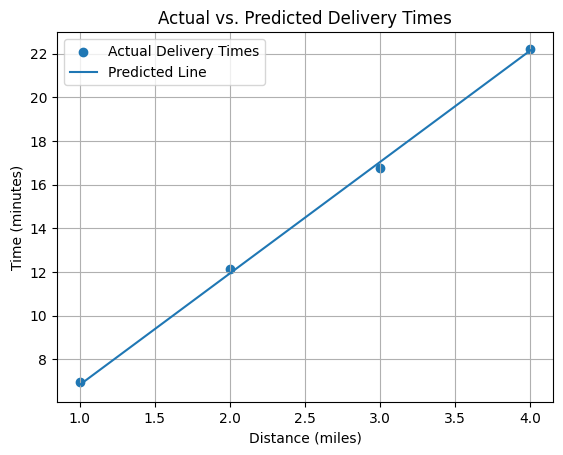

In [10]:
import matplotlib.pyplot as plt

# Get model predictions
with torch.no_grad():
    predicted_times = model(distances)

# Plot actual data
plt.scatter(distances.numpy(), times.numpy(), label="Actual Delivery Times")

# Plot predicted line
plt.plot(distances.numpy(), predicted_times.numpy(), label="Predicted Line")

# Labels
plt.xlabel("Distance (miles)")
plt.ylabel("Time (minutes)")
plt.title("Actual vs. Predicted Delivery Times")

plt.legend()
plt.grid()

plt.show()

## Make Your Prediction

Use the trained model to predict the delivery time for a new distance.

- `distance_to_predict = 7.0` → distance we want to predict.
- Convert the distance into a **tensor**.
- Give the tensor to the trained model.
- The model predicts the **delivery time**.
- Check whether the predicted time is **under 30 minutes**.
---

- `torch.no_grad()` → disables gradient calculation because we are not training.
- `[[7.0]]` → creates the new input in the 2D format expected by the model.
- `model(input)` → predicts the delivery time.
- `.item()` → extracts the actual number from the output tensor.

In [12]:
distance_to_predict = 7.0
# Use the torch.no_grad() context manager for efficient predictions
with torch.no_grad():
    # Convert the Python variable into a 2D PyTorch tensor that the model expects
    new_distance = torch.tensor([[distance_to_predict]], dtype=torch.float32)
    
    # Pass the new data to the trained model to get a prediction
    predicted_time = model(new_distance)
    
    # Use .item() to extract the scalar value from the tensor for printing
    print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time.item():.1f} minutes")

    # Use the scalar value in a conditional statement to make the final decision
    if predicted_time.item() > 30:
        print("\nDecision: Do NOT take the job. You will likely be late.")
    else:
        print("\nDecision: Take the job. You can make it!")

Prediction for a 7.0-mile delivery: 37.5 minutes

Decision: Do NOT take the job. You will likely be late.


## Inspecting the Model's Learning

In [13]:
# Access the first (and only) layer in the sequential model
layer = model[0]

# Get weights and bias
weights = layer.weight.data.numpy()
bias = layer.bias.data.numpy()

print(f"Weight: {weights}")
print(f"Bias: {bias}")

Weight: [[5.1080036]]
Bias: [1.7130015]


## Interpreting the Results

The model learned:

- **Weight (~5.0)** → Each additional mile adds about **5 minutes** to the delivery time.
- **Bias (~2.0)** → Base delivery time is about **2 minutes**.

The learned relationship is:

**Time = 5 × Distance + 2**

For example, for 7 miles:

**Time = 5 × 7 + 2 = 37 minutes**

## Testing on More Complex Data

The dataset now contains **two types of deliveries**:

- **1–3 miles** → Bike deliveries
- **Over 3 miles** → Car deliveries
- `new_distances` → distances from 1 to 20 miles.
- `new_times` → corresponding delivery times.

Now we will check whether our **simple linear model** can still learn this more complex pattern.

In [16]:
# Combined dataset: bikes for short distances, cars for longer ones
new_distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Corresponding delivery times in minutes
new_times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

Now let's test how well your bike-only model handles this new mixed dataset.

* Use your trained `model` to generates predictions on the `new_distances`.

In [15]:
# Use the already-trained linear model to make predictions
with torch.no_grad():
    predictions = model(new_distances)

* Calculate the `new_loss` between the model's predictions and the actual times.
* Notice how the printed loss value will be *significantly* higher than the loss at the end of training. This will indicate a poor fit.

In [17]:
# Calculate the new loss
new_loss = loss_function(predictions, new_times)
print(f"Loss on new, combined data: {new_loss.item():.2f}")

Loss on new, combined data: 169.17


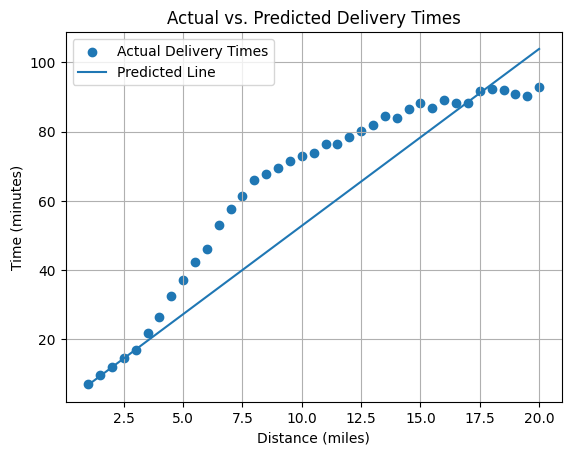

In [19]:
# Get model predictions
with torch.no_grad():
    predicted_times = model(new_distances)

# Plot actual data
plt.scatter(new_distances.numpy(), new_times.numpy(), label="Actual Delivery Times")

# Plot predicted line
plt.plot(new_distances.numpy(), predicted_times.numpy(), label="Predicted Line")

# Labels
plt.xlabel("Distance (miles)")
plt.ylabel("Time (minutes)")
plt.title("Actual vs. Predicted Delivery Times")

plt.legend()
plt.grid()

plt.show()

## Why Did the Linear Model Fail?

The new data contains a **non-linear pattern**.

- **Actual data** → delivery time changes differently for bikes and cars.
- **Linear model** → can only learn a **straight line**.
- Therefore, the model cannot fit the new complex pattern well.
- This results in a **higher loss**.

## Conclusion

A simple linear model works well when the data follows a **linear pattern**.

For more complex **non-linear patterns**, we need a neural network that can learn **curves and more complex relationships**.